# 8\. Machine learning and fitting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import requests

## Data import

FRED API Key

In [2]:
api_key='9f3bd16ec64e73545f6b5419de4ea643'

Fetch Data Series and Put into DataFrame

In [5]:

URL = 'https://api.stlouisfed.org/fred/series/observations'


def get_fred_series(series_id):

    params = {
    'series_id': series_id,
    'api_key': api_key,
    'file_type': 'json',
                }

    response = requests.get(URL,params=params)
    
    myjson=response.json()
    myobservations=myjson['observations']
    dataframe=(pd.DataFrame.from_dict(myobservations)
                      .loc[:,['date','value']]
                      .rename(columns={'value':series_id})
                )
    dataframe['date']=pd.to_datetime(dataframe['date'])
    dataframe=dataframe.set_index('date')
    dataframe[series_id]=pd.to_numeric(dataframe[series_id], errors='coerce')
    return dataframe

df=get_fred_series('LXXRSA')

# 'LXXRSA' -- Case-Schiller index, Los Angeles MSA
# 'LOSA106URN' -- LA unemployment rate
# 'LOSA106BPPRIVSA' -- LA housing permits
# 'CPIAUCSL'
# 'CUSR0000SEHA' -- US rent CPI
# 'UMCSENT' -- consumer sentiment
# 'TOTALSL' -- consumer credit

feature_ids=['LOSA106URN','LOSA106BPPRIVSA','CUSR0000SEHA','GS10','GS30','UMCSENT'] 

#,'LOSA106BPPRIVSA','CUSR0000SEHA','GS10','GS30','TOTALSL' 'CPIAUCSL','UMCSENT'] # ,'CUSR0000SEHA','TOTALSL' 'CPIAUCSL',,'UMCSENT'

# ,'LOSA106BPPRIVSA','GS10','GS30'

for series_name in feature_ids:
    df=df.join(get_fred_series(series_name), how='outer')

In [6]:
df

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT
date,,,,,,,
1952-11-01,NaN,NaN,NaN,NaN,NaN,NaN,86.2
1952-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953-02-01,NaN,NaN,NaN,NaN,NaN,NaN,90.7
1953-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2023-06-01,408.093659,4.9,3005.171190,398.888,3.75,3.87,64.2
2023-07-01,412.324111,5.0,2350.917586,400.566,3.90,3.96,71.5
2023-08-01,417.282406,5.4,3044.697799,402.508,4.17,4.28,69.4


Fill in the blanks to turn the index, LXXRSA, into a year-over-year (12-month) change. This change will be the outcome to predict: what is the 12-month change in Los Angeles housing prices?

In [7]:
outcome='la_housing_yoy'

df['la_housing_yoy']=(df['LXXRSA']-df['LXXRSA'].shift(12))/df['LXXRSA'].shift(12)

df=df[df['LOSA106URN'].notna()]

In [8]:
df

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy
date,,,,,,,,
1990-01-01,100.471193,5.2,5121.625810,135.800,8.21,8.26,93.0,0.148593
1990-02-01,100.761572,5.0,4649.036013,136.100,8.47,8.50,89.5,0.135047
1990-03-01,100.992838,4.8,3628.465563,136.700,8.59,8.56,91.3,0.108016
1990-04-01,100.990410,4.9,3833.501147,137.200,8.79,8.76,93.9,0.085775
1990-05-01,100.394583,4.9,3466.204183,137.600,8.76,8.73,90.6,0.061597
...,...,...,...,...,...,...,...,...
2023-05-01,404.649596,4.4,2528.929630,397.052,3.57,3.86,59.0,-0.031496
2023-06-01,408.093659,4.9,3005.171190,398.888,3.75,3.87,64.2,-0.019437
2023-07-01,412.324111,5.0,2350.917586,400.566,3.90,3.96,71.5,0.003335


In [9]:
df[df['LOSA106URN'].notna()].describe()

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy
count,404.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,404.000000
mean,186.258733,6.951605,2087.863737,235.181486,4.249358,4.780025,85.744691,0.049994
std,92.915604,2.525078,854.448369,69.976953,2.000996,1.837468,13.259049,0.111599
min,73.843781,3.700000,256.190561,135.800000,0.620000,1.270000,50.000000,-0.279098
25%,95.911399,5.000000,1499.677323,171.800000,2.530000,3.110000,76.100000,-0.023657
50%,172.643055,6.200000,2077.001571,228.800000,4.100000,4.690000,88.400000,0.054993
75%,256.418607,8.600000,2563.488473,283.786000,5.810000,6.050000,95.300000,0.116383
max,417.809036,18.000000,5797.354220,404.471000,8.890000,9.030000,112.000000,0.332966


In [10]:
df.describe()

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy
count,404.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,404.000000
mean,186.258733,6.951605,2087.863737,235.181486,4.249358,4.780025,85.744691,0.049994
std,92.915604,2.525078,854.448369,69.976953,2.000996,1.837468,13.259049,0.111599
min,73.843781,3.700000,256.190561,135.800000,0.620000,1.270000,50.000000,-0.279098
25%,95.911399,5.000000,1499.677323,171.800000,2.530000,3.110000,76.100000,-0.023657
50%,172.643055,6.200000,2077.001571,228.800000,4.100000,4.690000,88.400000,0.054993
75%,256.418607,8.600000,2563.488473,283.786000,5.810000,6.050000,95.300000,0.116383
max,417.809036,18.000000,5797.354220,404.471000,8.890000,9.030000,112.000000,0.332966


## Split the sample

In [11]:
df_outcome_unknown=df[df[outcome].isna()]

df_testing=df[df[outcome].notna()].iloc[-100:,:]

df_training=df[df[outcome].notna()].iloc[:-100,:]

In [12]:
df_outcome_unknown

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy
date,,,,,,,,
2023-09-01,NaN,5.3,1864.964844,404.471,4.38,4.47,67.9,NaN


## Define functions to make lags of features

Add a lagged value to the dataframe.

In [13]:
def make_lags(varname, num):
    
    new_varname=varname+'_lag'+str(num)
    
    df[new_varname]= df[varname].shift(num)

In [14]:
lagged_vars=feature_ids+[outcome]

print(lagged_vars)

['LOSA106URN', 'LOSA106BPPRIVSA', 'CUSR0000SEHA', 'GS10', 'GS30', 'UMCSENT', 'la_housing_yoy']


Add lagged values for all variables to the dataframe.

In [15]:
number_of_lags=50

for feature_name in lagged_vars:    
    for i in range(1,number_of_lags+1):
        make_lags(feature_name, i)    

C:\Users\mattv\AppData\Local\Temp\ipykernel_16360\3686237813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_varname]= df[varname].shift(num)
C:\Users\mattv\AppData\Local\Temp\ipykernel_16360\3686237813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_varname]= df[varname].shift(num)
C:\Users\mattv\AppData\Local\Temp\ipykernel_16360\3686237813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [16]:
df

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy,LOSA106URN_lag1,LOSA106URN_lag2,...,la_housing_yoy_lag41,la_housing_yoy_lag42,la_housing_yoy_lag43,la_housing_yoy_lag44,la_housing_yoy_lag45,la_housing_yoy_lag46,la_housing_yoy_lag47,la_housing_yoy_lag48,la_housing_yoy_lag49,la_housing_yoy_lag50
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,100.471193,5.2,5121.625810,135.800,8.21,8.26,93.0,0.148593,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-01,100.761572,5.0,4649.036013,136.100,8.47,8.50,89.5,0.135047,5.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-03-01,100.992838,4.8,3628.465563,136.700,8.59,8.56,91.3,0.108016,5.0,5.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-04-01,100.990410,4.9,3833.501147,137.200,8.79,8.76,93.9,0.085775,4.8,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-05-01,100.394583,4.9,3466.204183,137.600,8.76,8.73,90.6,0.061597,4.9,4.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-01,404.649596,4.4,2528.929630,397.052,3.57,3.86,59.0,-0.031496,4.2,4.6,...,0.027736,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003,0.011721,0.011637
2023-06-01,408.093659,4.9,3005.171190,398.888,3.75,3.87,64.2,-0.019437,4.4,4.2,...,0.034911,0.027736,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003,0.011721
2023-07-01,412.324111,5.0,2350.917586,400.566,3.90,3.96,71.5,0.003335,4.9,4.4,...,0.037537,0.034911,0.027736,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003


Split the data into a testing dataset (the last 100 months of completely observed data) and a training dataset (the other completely observed datapoints.)

Note that we are not taking the months at random! By trying to predict a separate time period, we are not only pushing the statistical properties of the model, but seeing whether it will be resilient during a differen time period, when e.g. a global pandemic might change the relationships we are using for prediction.

In [17]:
df_outcome_unknown=df[df[outcome].isna()]

df_testing=df[df[outcome].notna()].iloc[-100:,:]

df_training=df[df[outcome].notna()].iloc[:-100,:]

In [18]:
df_training

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy,LOSA106URN_lag1,LOSA106URN_lag2,...,la_housing_yoy_lag41,la_housing_yoy_lag42,la_housing_yoy_lag43,la_housing_yoy_lag44,la_housing_yoy_lag45,la_housing_yoy_lag46,la_housing_yoy_lag47,la_housing_yoy_lag48,la_housing_yoy_lag49,la_housing_yoy_lag50
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,100.471193,5.2,5121.625810,135.800,8.21,8.26,93.0,0.148593,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-01,100.761572,5.0,4649.036013,136.100,8.47,8.50,89.5,0.135047,5.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-03-01,100.992838,4.8,3628.465563,136.700,8.59,8.56,91.3,0.108016,5.0,5.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-04-01,100.990410,4.9,3833.501147,137.200,8.79,8.76,93.9,0.085775,4.8,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-05-01,100.394583,4.9,3466.204183,137.600,8.76,8.73,90.6,0.061597,4.9,4.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-01,228.004973,6.6,2189.584628,280.383,2.21,2.83,93.6,0.054761,7.0,7.2,...,-0.035982,-0.035683,-0.033989,-0.022459,-0.017154,-0.020165,-0.016801,-0.000874,0.022317,0.034200
2015-01-01,228.258767,7.2,3330.985159,281.223,1.88,2.46,98.1,0.053999,6.6,7.0,...,-0.034920,-0.035982,-0.035683,-0.033989,-0.022459,-0.017154,-0.020165,-0.016801,-0.000874,0.022317
2015-02-01,230.326455,6.8,2982.834883,282.171,1.98,2.57,95.4,0.055139,7.2,6.6,...,-0.040867,-0.034920,-0.035982,-0.035683,-0.033989,-0.022459,-0.017154,-0.020165,-0.016801,-0.000874


In [19]:
df_testing

,LXXRSA,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy,LOSA106URN_lag1,LOSA106URN_lag2,...,la_housing_yoy_lag41,la_housing_yoy_lag42,la_housing_yoy_lag43,la_housing_yoy_lag44,la_housing_yoy_lag45,la_housing_yoy_lag46,la_housing_yoy_lag47,la_housing_yoy_lag48,la_housing_yoy_lag49,la_housing_yoy_lag50
date,,,,,,,,,,,,,,,,,,,,,
2015-05-01,234.198474,6.3,2396.638621,284.559,2.20,2.96,90.7,0.060545,6.2,6.5,...,-0.050330,-0.052537,-0.048143,-0.040867,-0.034920,-0.035982,-0.035683,-0.033989,-0.022459,-0.017154
2015-06-01,235.044940,6.4,5096.457689,285.477,2.36,3.11,96.1,0.061564,6.3,6.2,...,-0.052777,-0.050330,-0.052537,-0.048143,-0.040867,-0.034920,-0.035982,-0.035683,-0.033989,-0.022459
2015-07-01,235.647650,6.7,2077.001571,286.435,2.32,3.07,93.1,0.061298,6.4,6.3,...,-0.051672,-0.052777,-0.050330,-0.052537,-0.048143,-0.040867,-0.034920,-0.035982,-0.035683,-0.033989
2015-08-01,236.237989,6.2,2416.710035,287.320,2.17,2.86,91.9,0.063600,6.7,6.4,...,-0.049103,-0.051672,-0.052777,-0.050330,-0.052537,-0.048143,-0.040867,-0.034920,-0.035982,-0.035683
2015-09-01,237.294011,5.7,3800.674761,288.385,2.17,2.95,87.2,0.065148,6.2,6.7,...,-0.037914,-0.049103,-0.051672,-0.052777,-0.050330,-0.052537,-0.048143,-0.040867,-0.034920,-0.035982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-01,400.784095,4.2,2479.540810,395.115,3.46,3.68,63.7,-0.032875,4.6,4.8,...,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003,0.011721,0.011637,0.017023
2023-05-01,404.649596,4.4,2528.929630,397.052,3.57,3.86,59.0,-0.031496,4.2,4.6,...,0.027736,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003,0.011721,0.011637
2023-06-01,408.093659,4.9,3005.171190,398.888,3.75,3.87,64.2,-0.019437,4.4,4.2,...,0.034911,0.027736,0.028207,0.020556,0.017366,0.010682,0.010722,0.013234,0.017003,0.011721


## Big regression

In [20]:
X=df[lagged_vars].copy()

In [21]:
X

,LOSA106URN,LOSA106BPPRIVSA,CUSR0000SEHA,GS10,GS30,UMCSENT,la_housing_yoy
date,,,,,,,
1990-01-01,5.2,5121.625810,135.800,8.21,8.26,93.0,0.148593
1990-02-01,5.0,4649.036013,136.100,8.47,8.50,89.5,0.135047
1990-03-01,4.8,3628.465563,136.700,8.59,8.56,91.3,0.108016
1990-04-01,4.9,3833.501147,137.200,8.79,8.76,93.9,0.085775
1990-05-01,4.9,3466.204183,137.600,8.76,8.73,90.6,0.061597
...,...,...,...,...,...,...,...
2023-05-01,4.4,2528.929630,397.052,3.57,3.86,59.0,-0.031496
2023-06-01,4.9,3005.171190,398.888,3.75,3.87,64.2,-0.019437
2023-07-01,5.0,2350.917586,400.566,3.90,3.96,71.5,0.003335


In [22]:
print(lagged_vars)

['LOSA106URN', 'LOSA106BPPRIVSA', 'CUSR0000SEHA', 'GS10', 'GS30', 'UMCSENT', 'la_housing_yoy']


Add first and second lagged values of all variables to the set of features to use in machine learning regression.

In [23]:
features_with_lags=list()

number_of_lags=2
for feature_name in lagged_vars:
    
    #print(feature_name)
    features_with_lags.append(str(feature_name))
    for i in range(1,number_of_lags+1):
        new_feature_name=feature_name+'_lag'+str(i)
        features_with_lags.append(new_feature_name)

#print(features_with_lags)

Create a final list containing the features for the model, including the lags, but excluding the unlagged outcome variable.

In [24]:
X=df_training[features_with_lags].copy().dropna().drop(outcome, axis=1)

final_list_of_features=features_with_lags.copy()
final_list_of_features.remove(outcome)

In [25]:
print(final_list_of_features)

['LOSA106URN', 'LOSA106URN_lag1', 'LOSA106URN_lag2', 'LOSA106BPPRIVSA', 'LOSA106BPPRIVSA_lag1', 'LOSA106BPPRIVSA_lag2', 'CUSR0000SEHA', 'CUSR0000SEHA_lag1', 'CUSR0000SEHA_lag2', 'GS10', 'GS10_lag1', 'GS10_lag2', 'GS30', 'GS30_lag1', 'GS30_lag2', 'UMCSENT', 'UMCSENT_lag1', 'UMCSENT_lag2', 'la_housing_yoy_lag1', 'la_housing_yoy_lag2']


Store the beginning and ending dates of the training data

In [26]:
date_min=X.reset_index().loc[:,'date'].iloc[0]
date_max=X.reset_index().loc[:,'date'].iloc[-1]

In [27]:
print(date_min)
print(date_max)

1990-03-01 00:00:00
2015-04-01 00:00:00


Create an outcome vector for the relevant dates

In [28]:
y=df[outcome].copy().loc[date_min:date_max]

Use statsmodels to fit your regression.

In [29]:
reg=sm.OLS(y,X).fit()

In [30]:
print(reg.summary())

                                 OLS Regression Results                                
Dep. Variable:         la_housing_yoy   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                              8453.
Date:                Mon, 20 Nov 2023   Prob (F-statistic):                        0.00
Time:                        15:12:06   Log-Likelihood:                          1154.1
No. Observations:                 302   AIC:                                     -2268.
Df Residuals:                     282   BIC:                                     -2194.
Df Model:                          20                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

## Out-of-sample fit

Use the more recent years of data to construct out-of-sample predictions

In [31]:
Xtest=df_testing[final_list_of_features].copy()

In [32]:
test_predictions=reg.predict(Xtest)

In [33]:
testing_date_min=Xtest.reset_index().loc[:,'date'].iloc[0]
testing_date_max=Xtest.reset_index().loc[:,'date'].iloc[-1]

In [34]:
ytest=df[outcome].copy().loc[testing_date_min:testing_date_max]

In [35]:
df_out_of_sample=pd.DataFrame([ytest, test_predictions]).T

Compute the R-squared

In [36]:
RSS=np.sum((ytest-test_predictions)**2)
TSS=np.sum((ytest-np.mean(ytest))**2)
R2=1-RSS/TSS

print("Out-of-sample R-squared: "+str(R2))

Out-of-sample R-squared: 0.9788311389536978


## Tune the set of regressors

Create a function that will repeat the steps above, but for a flexible number of lags. This will let us search for the time structure that gives the best R-squared out of sample. 

In [37]:
def predict_los_angeles_housing(number_of_lags):
    
    # ===============================================================
    # Create the list of features to keep for a given number of lags
    features_with_lags=list()
    for feature_name in lagged_vars:
        features_with_lags.append(str(feature_name))
        for i in range(1,number_of_lags+1):
            new_feature_name=feature_name+'_lag'+str(i)
            features_with_lags.append(new_feature_name)
    

    # ===============================================================
    # Create training data from that list of features
    X=df_training[features_with_lags].copy().dropna().drop(outcome, axis=1)

    final_list_of_features=features_with_lags.copy()
    final_list_of_features.remove(outcome)
    
    date_min=X.reset_index().loc[:,'date'].iloc[0]
    date_max=X.reset_index().loc[:,'date'].iloc[-1]
    
    y=df[outcome].copy().loc[date_min:date_max]
    
    
    # ===============================================================
    # Fit a regression to the training data
    reg=sm.OLS(y,X).fit()
    
    
    # ===============================================================
    # Predict values for the testing data
    Xtest=df_testing[final_list_of_features].copy()
    test_predictions=reg.predict(Xtest)
    
    # ===============================================================
    # Compute the out-of-sample R-squared
    
    testing_date_min=Xtest.reset_index().loc[:,'date'].iloc[0]
    testing_date_max=Xtest.reset_index().loc[:,'date'].iloc[-1]
    ytest=df[outcome].copy().loc[testing_date_min:testing_date_max]
    
    RSS=np.sum((ytest-test_predictions)**2)
    TSS=np.sum((ytest-np.mean(ytest))**2)
    R2=1-RSS/TSS

    return R2

In [38]:
predict_los_angeles_housing(1)

0.9055423555257379

Use the program to compute and store the R-squared values for models with 1 to 24 months (2 years) of lagged data in an array.

In [39]:
stored_r2s=np.empty((24,2))

for i in range(1,25):
    
    stored_r2s[i-1,0]=i
    
    stored_r2s[i-1,1]=predict_los_angeles_housing(i)

Plot the stored values of R-squared obtained for each number of lags.

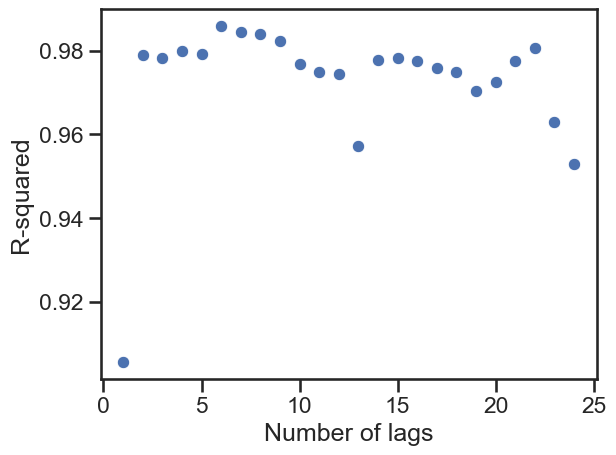

In [40]:
# Create a plot of out-of-sample R-squared by number of time lags in the model

sns.set_theme(style='ticks', context='talk')
g=sns.scatterplot(x=stored_r2s[:,0], y=stored_r2s[:,1])
g.set_xlabel('Number of lags')
g.set_ylabel('R-squared')

plt.show()

*It appears that including a few lags definitely improves goodness of fit -- 2 seems to be good, though about 6 lags is the highest R-squared -- but after that overfitting kicks in and model quality declines.*